In [1]:
import stlrom as stl
from stlrom import signal_gen as sg
d = stl.STLDriver()
d.parse_string('signal x,y,z')

tf = 0.1
dv_max=1; dt_min=.05; dt_max=.1
#rand_sg = sg.RandSignalGen(dv_max=dv_max, dt_min=dt_min, dt_max=dt_max, interp='LINEAR')
rand_sg = sg.RandSignalGen(dv_max=dv_max, dt_min=dt_min, dt_max=dt_max)


<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

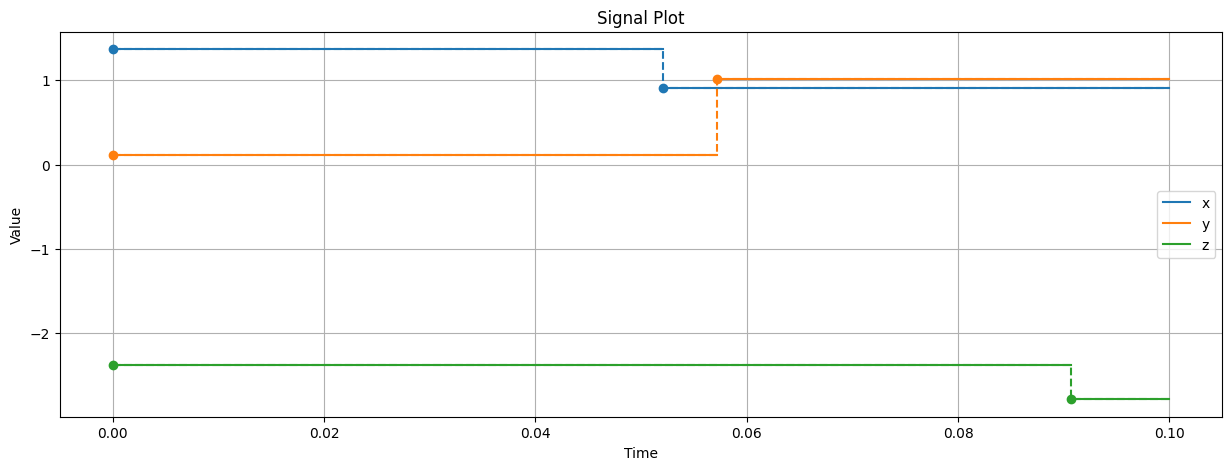

In [2]:
x = rand_sg.set_param(seed=0).get_signal(tf=tf)
y = rand_sg.set_param(seed=1).get_signal(tf=tf)
z = rand_sg.set_param(seed=2).get_signal(tf=tf)
d.set_signals([x,y,z])
d.plot_signals(draw_samples=True)

In [3]:
d.parse_string(''' 
               mu_x := x[t]>0
               mu := x[t]>y[t]
               ''')


True

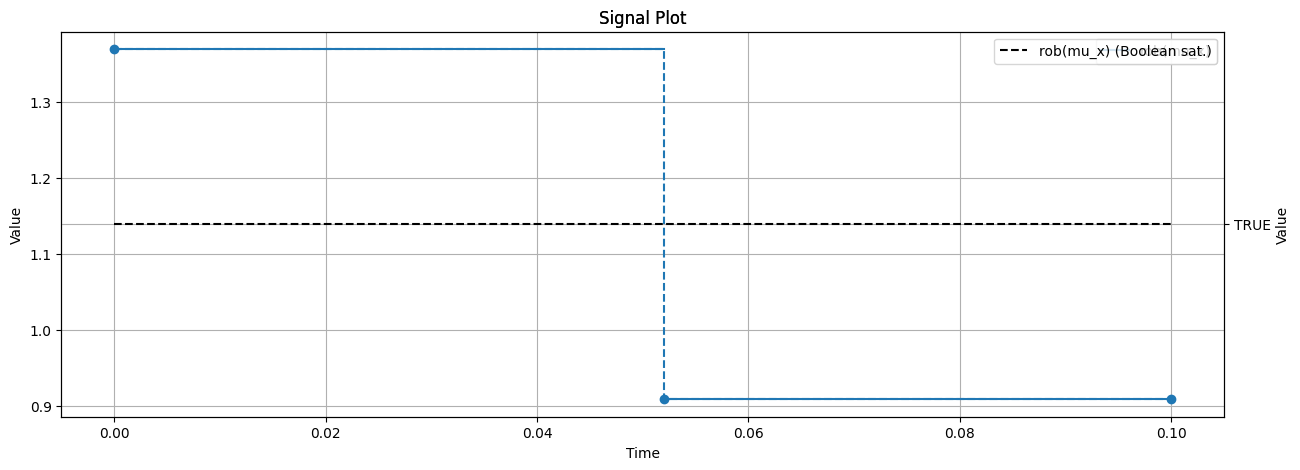

In [4]:
Mu_rob = d.get_rob_signal('mu_x', 0, tf)
ax= Mu_rob.plot(draw_samples=True, label='rob(mu_x)', plot_sat=True)

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

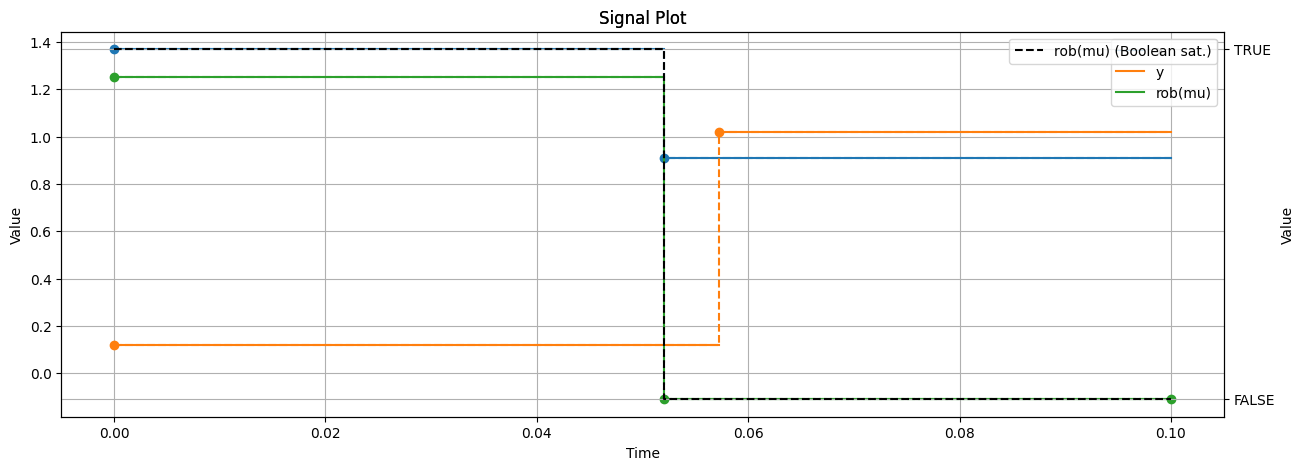

In [5]:
Mu_rob = d.get_rob_signal('mu', 0, tf)
ax  = d.plot_signals(['x', 'y'], draw_samples=True)
Mu_rob.plot(draw_samples=True, label='rob(mu)', plot_sat=True,ax =ax)